# Collider Ring Studies (twiss_ir1ccma_hybrid_v06).

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

from mint import lattice_tools as lt
from mint import beam_optics as bopt
from mint import const, xsecs
from mint.MuC import MuDecaySimulator
from mint import plot_tools as pt

## Create main collider-ring lattice

In [2]:
twiss_file = "beam-optics/twiss_ir1ccma_hybrid_v06.outx"

ring_df = lt.get_lattice_dataframe_from_tfs(twiss_file)
ring_dict = bopt.create_smoothed_lattice(
    ring_df,
    emittance_RMS=25e-6/(5e3/0.105), # meters.rad
    n_elements=120000,
    rotated=True,
    if_sublattice=False,
    midpoint=True
)
ring_lattice = lt.Lattice(**ring_dict)
ring_lattice.name = "twiss_ir1ccma_hybrid_v06"
ring_lattice.short_name = "ir1ccma_v06"

# Operation assumptions
ring_lattice.Nmu_per_bunch = 2e12
ring_lattice.finj = 5.0
ring_lattice.bunch_multiplicity = 1.0
ring_lattice.duty_factor = 1 / np.pi

print(f"Lattice: {ring_lattice.name}")
print(f"Ring circumference: {ring_lattice.s(1)/1e3:.2f} km")

Setting additional dispersion_Dx to <scipy.interpolate._interpolate.interp1d object at 0x11dc5e300>
Setting additional dispersion_Dpx to <scipy.interpolate._interpolate.interp1d object at 0x11dc5e350>
Setting additional betx to <scipy.interpolate._interpolate.interp1d object at 0x11dc5e3f0>
Setting additional bety to <scipy.interpolate._interpolate.interp1d object at 0x11dc5e440>
Setting additional gamx to <scipy.interpolate._interpolate.interp1d object at 0x11dc5e490>
Setting additional gamy to <scipy.interpolate._interpolate.interp1d object at 0x11dc5e4e0>
Setting additional alfx to <scipy.interpolate._interpolate.interp1d object at 0x11dc5e530>
Setting additional alfy to <scipy.interpolate._interpolate.interp1d object at 0x11dc5e580>
Setting additional cov_x_xp to <scipy.interpolate._interpolate.interp1d object at 0x11dc5e5d0>
Setting additional cov_y_yp to <scipy.interpolate._interpolate.interp1d object at 0x11dc5e620>
Setting additional sigma_xp to <scipy.interpolate._interpolate.

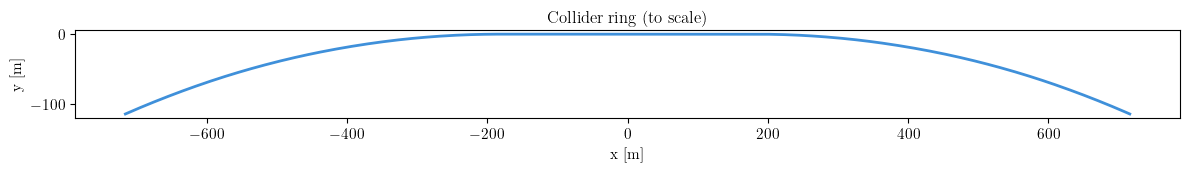

In [3]:
# Quick geometry and reference momentum profile
u = np.linspace(0, 1, 4000)

fig, ax = plt.subplots(1, 1, figsize=(12, 4))
ax.plot(ring_lattice.x(u)/100, ring_lattice.y(u)/100, lw=2.0)
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_title("Collider ring (to scale)")
ax.set_aspect("equal", adjustable="box")

fig.tight_layout()

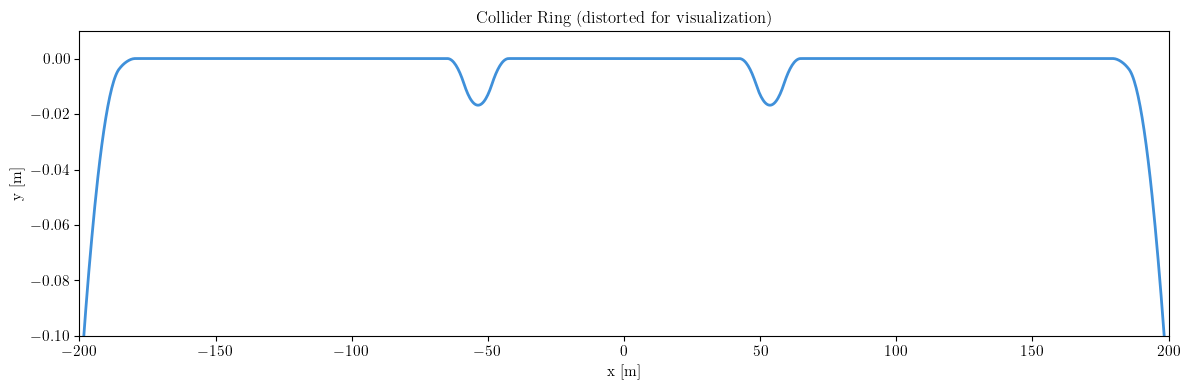

In [4]:
# Quick geometry and reference momentum profile
u = np.linspace(0, 1, 4000)

fig, ax = plt.subplots(1, 1, figsize=(12, 4))
ax.plot(ring_lattice.x(u)/100, ring_lattice.y(u)/100, lw=2)
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_title("Collider Ring (distorted for visualization)")
ax.set_ylim(-0.1,0.01)
ax.set_xlim(-200,200)
fig.tight_layout()

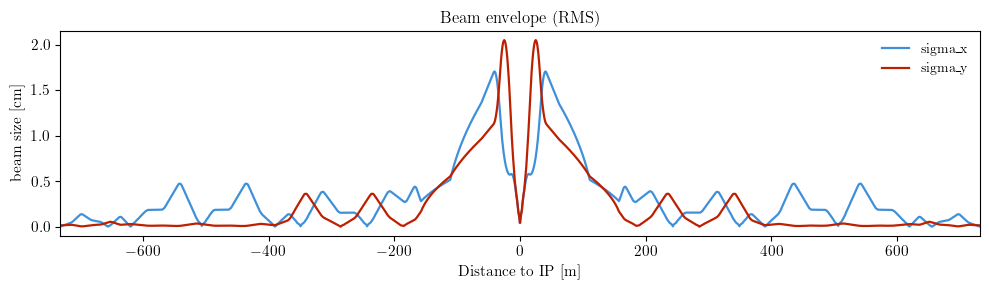

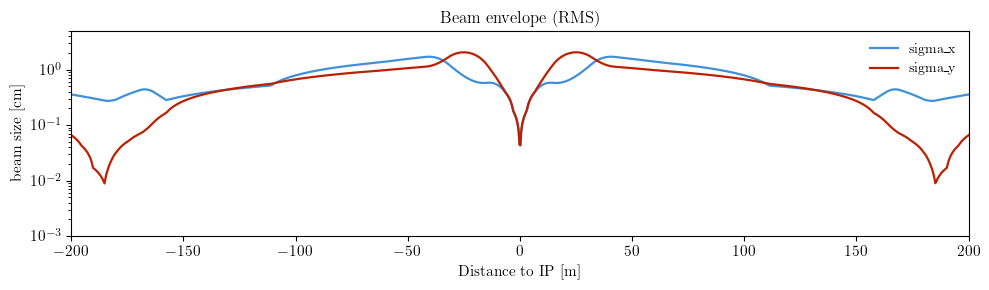

In [5]:
# Plot beam envelope (RMS) vs longitudinal position s [m]
delta_s_m = (ring_lattice.s(u) - ring_lattice.s(u).mean())*1e-2
sigma_x = ring_dict["beamsize_x"](u)
sigma_y = ring_dict["beamsize_y"](u)

fig_env, ax_env = plt.subplots(figsize=(10, 3))
ax_env.plot(delta_s_m, sigma_x, label="sigma_x", lw=1.6)
ax_env.plot(delta_s_m, sigma_y, label="sigma_y", lw=1.6)
ax_env.set_xlabel("Distance to IP [m]")
ax_env.set_ylabel("beam size [cm]")
ax_env.set_title("Beam envelope (RMS)")
ax_env.legend(frameon=False)
ax_env.set_xlim(delta_s_m.min(), delta_s_m.max())
fig_env.tight_layout()
fig_env.savefig("plots/hybrid_v06_beam_envelope.pdf", dpi=300, bbox_inches="tight")



fig_env, ax_env = plt.subplots(figsize=(10, 3))
ax_env.plot(delta_s_m, sigma_x, label="sigma_x", lw=1.6)
ax_env.plot(delta_s_m, sigma_y, label="sigma_y", lw=1.6)
ax_env.set_xlabel("Distance to IP [m]")
ax_env.set_ylabel("beam size [cm]")
ax_env.set_ylim(1e-3, 5)
ax_env.set_yscale('log')
ax_env.set_title("Beam envelope (RMS)")
ax_env.legend(frameon=False)
ax_env.set_xlim(delta_s_m.mean() - 200, delta_s_m.mean() + 200)
fig_env.tight_layout()
fig_env.savefig("plots/hybrid_v06_beam_envelope_zoomed.pdf", dpi=300, bbox_inches="tight")


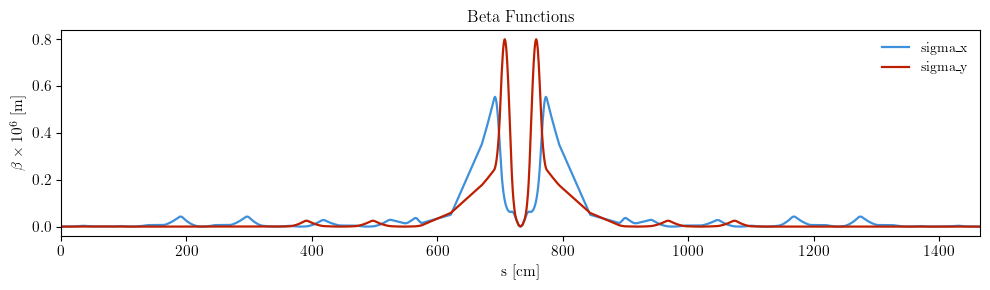

In [6]:
# Plot beam envelope (RMS) vs longitudinal position s [m]
s_m = ring_lattice.s(u) * 1e-2
sigma_x = ring_dict["betx"](u) * 1e-6
sigma_y = ring_dict["bety"](u) * 1e-6

fig_env, ax_env = plt.subplots(figsize=(10, 3))
ax_env.plot(s_m, sigma_x, label="sigma_x", lw=1.6)
ax_env.plot(s_m, sigma_y, label="sigma_y", lw=1.6)
ax_env.set_xlabel(r"s [cm]")
ax_env.set_ylabel(r"$\beta \times 10^{6}$ [m]")
ax_env.set_title("Beta Functions")
ax_env.legend(frameon=False)
ax_env.set_xlim(s_m.min(), s_m.max())
fig_env.tight_layout()
fig_env.savefig("plots/hybrid_v06_beta_functions.pdf", dpi=300, bbox_inches="tight")


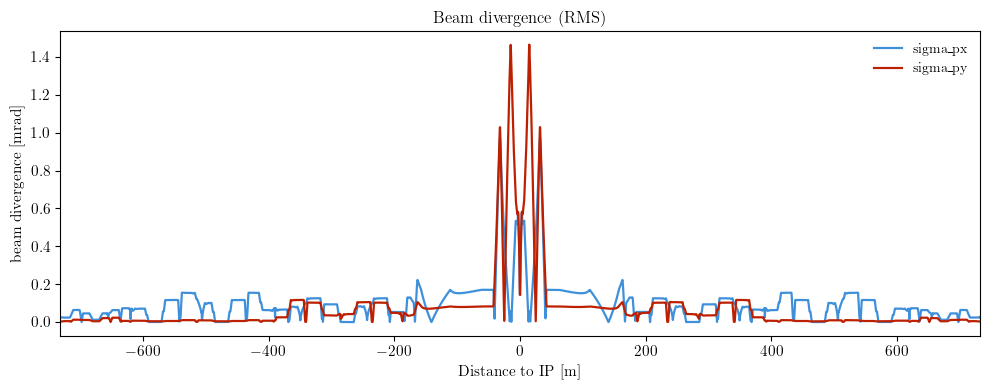

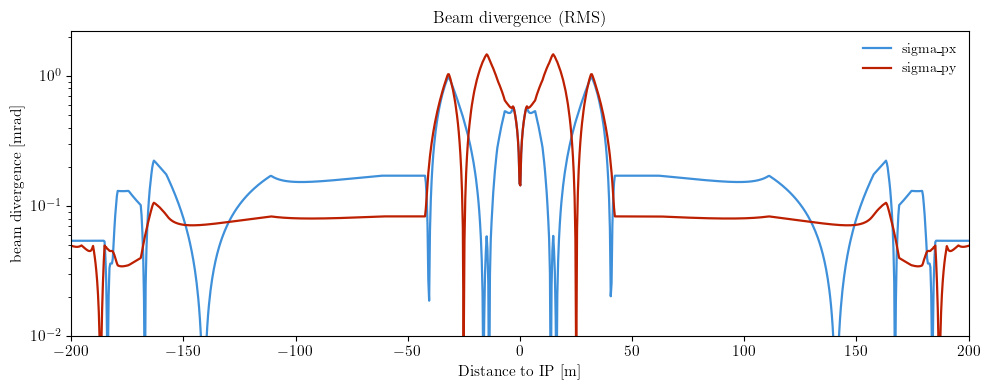

In [7]:
# Plot beam envelope (RMS) vs longitudinal position s [m]
delta_s_m = (ring_lattice.s(u) - ring_lattice.s(u).mean())*1e-2
sigma_x_mrad = ring_dict["beamdiv_x"](u)*1e3
sigma_y_mrad = ring_dict["beamdiv_y"](u)*1e3

fig_env, ax_env = plt.subplots(figsize=(10, 4))
ax_env.plot(delta_s_m, sigma_x_mrad, label=r"sigma_{px}", lw=1.6)
ax_env.plot(delta_s_m, sigma_y_mrad, label=r"sigma_{py}", lw=1.6)
ax_env.set_xlabel("Distance to IP [m]")
ax_env.set_ylabel("beam divergence [mrad]")
ax_env.set_title("Beam divergence (RMS)")
ax_env.legend(frameon=False)
ax_env.set_xlim(delta_s_m.min(), delta_s_m.max())
fig_env.tight_layout()
fig_env.savefig("plots/hybrid_v06_beam_divergence.pdf", dpi=300, bbox_inches="tight")

# ZOOMED IN
# Plot beam envelope (RMS) vs longitudinal position s [m]
delta_s_m = (ring_lattice.s(u) - ring_lattice.s(u).mean())*1e-2
sigma_x_mrad = ring_dict["beamdiv_x"](u)*1e3
sigma_y_mrad = ring_dict["beamdiv_y"](u)*1e3

fig_env, ax_env = plt.subplots(figsize=(10, 4))
ax_env.plot(delta_s_m, sigma_x_mrad, label=r"sigma_{px}", lw=1.6)
ax_env.plot(delta_s_m, sigma_y_mrad, label=r"sigma_{py}", lw=1.6)
ax_env.set_xlabel("Distance to IP [m]")
ax_env.set_ylabel("beam divergence [mrad]")
ax_env.set_title("Beam divergence (RMS)")
ax_env.legend(frameon=False)
ax_env.set_yscale('log')
ax_env.set_ylim(0.01, None)
ax_env.set_xlim(delta_s_m.mean() - 200, delta_s_m.mean() + 200)
fig_env.tight_layout()
fig_env.savefig("plots/hybrid_v06_beam_divergence_zoomed.pdf", dpi=300, bbox_inches="tight")

## Simulate forward neutrino flux

In [8]:
n_evals = 1e6

ring_sims = {
    "numubar": MuDecaySimulator(cycles=1e3, muon_polarization=0.0, nuflavor="numubar", direction="right", n_evals=n_evals, beam_dynamics=True),
    "nue": MuDecaySimulator(cycles=1e3, muon_polarization=0.0, nuflavor="nue", direction="right", n_evals=n_evals, beam_dynamics=True),
    "numubar_nobd": MuDecaySimulator(cycles=1e3, muon_polarization=0.0, nuflavor="numubar", direction="right", n_evals=n_evals, beam_dynamics=False),
    "nue_nobd": MuDecaySimulator(cycles=1e3, muon_polarization=0.0, nuflavor="nue", direction="right", n_evals=n_evals, beam_dynamics=False),
    "numu": MuDecaySimulator(cycles=1e3, muon_polarization=0.0, nuflavor="numu", direction="left", n_evals=n_evals, beam_dynamics=True),
    "numu_nobd": MuDecaySimulator(cycles=1e3, muon_polarization=0.0, nuflavor="numu", direction="left", n_evals=n_evals, beam_dynamics=False),
}

for flavor, sim in ring_sims.items():
    sim.decay_muons()

    if ring_sims[flavor]=="numu" or ring_sims[flavor]=="numu_nobd":
        sim.place_muons_on_lattice(lattice=ring_lattice, direction="counter-clockwise")
    else:
        sim.place_muons_on_lattice(lattice=ring_lattice, direction="clockwise")

sample_size: 937283
pos x range: -11388.32069179202 -2885.1810977369146 2.5811741831906434e-05
pos y range: -7.2748360700972965 -0.0007317597165979833 7.598372289072105
pos z range: -71649.46258907755 -69.40446531434246 71648.39869196565
s_in_turn min/max: 0.1038861483684741 146489.4458773081
u_parameter min/max: 7.091713457580844e-07 0.9999997025945427
mutimes min/max: 5.720331214170329e-09 0.004886362659572304
muon_lifetime min/max: 0.10396625395778492 0.10396625395778492
sample_size: 937610
pos x range: -11388.235110895 -2880.545926843143 2.5091401137084528e-05
pos y range: -7.685976725600906 -1.288648467658951e-05 7.292770412449643
pos z range: -71649.26664725004 45.960095383444205 71648.1366153686
s_in_turn min/max: 0.31951975321862847 146489.15387492324
u_parameter min/max: 2.181178693646798e-06 0.9999977092611919
mutimes min/max: 3.247962646200365e-09 0.004886362768814831
muon_lifetime min/max: 0.10396625395778492 0.10396625395778492
sample_size: 937562
pos x range: -11388.30918

In [9]:
# Detector and running assumptions for event-rate estimate
det_radius = 2e2  # cm (2 m radius)
detector_length_cm = 10e2  # 10 m target depth
rho_g_cm3 = 1.00
nucleon_column_density = rho_g_cm3 * detector_length_cm / const.m_proton_in_g
detector_area_cm2 = np.pi * det_radius**2

det_location = np.array([0.0, 0.0, 1e5])  # 1 km downstream
det_location2 = np.array([0.0, 0.0, -1e5])  # 1 km upstream for mu- decay

bunches_per_year = (
    ring_lattice.finj
    * ring_lattice.bunch_multiplicity
    * ring_lattice.duty_factor
    * const.s_in_year
)


/var/folders/84/k7jzjrjn68595pl9grlw_7cm0000gq/T/ipykernel_45046/273792356.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


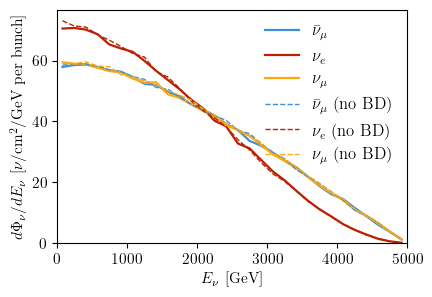

In [10]:
# Forward detector setup (on-axis, downstream)
energy_edges = np.linspace(0, 5e3, 31)
energy_centers = 0.5 * (energy_edges[1:] + energy_edges[:-1])

flux_results = {}
for flavor, sim in ring_sims.items():
    if ring_sims[flavor] == "numu" or ring_sims[flavor] == "numu_nobd":
        loc = det_location2
    else:
        loc = det_location
    e_edges, flux = sim.get_flux_at_generic_location(
        det_location=loc,
        det_radius=det_radius,
        ebins=energy_edges,
        per_cm2=True,
        normalization=1,
    )

    if np.isscalar(e_edges):
        flux = np.zeros_like(energy_centers)
    flux_results[flavor] = flux

fig, ax = pt.std_fig()
label = {"numubar": r"$\bar\nu_\mu$", "nue": r"$\nu_e$", "numu": r"$\nu_\mu$"}
for i, flavor in enumerate(["numubar", "nue", "numu"]):
    ax.plot(energy_centers, flux_results[flavor], lw=1.6, label=label[flavor])
    # ax[i].set_yscale("log")
    ax.set_xlabel(r"$E_\nu$ [GeV]")

plt.gca().set_prop_cycle(None)
for i, flavor in enumerate(["numubar", "nue", "numu"]):
    ax.plot(energy_centers, flux_results[flavor+'_nobd'], lw=1, ls='--', label=label[flavor]+r' (no BD)')
    # ax[i].set_yscale("log")
    ax.set_xlabel(r"$E_\nu$ [GeV]")

ax.set_xlim(0, 5e3)
ax.set_ylim(0, None)
ax.legend(frameon=False, fontsize=12)
ax.set_ylabel(r"$d\Phi_\nu/dE_\nu$ [$\nu$/cm$^{2}$/GeV per bunch]")
fig.tight_layout()
fig.savefig("plots/hybrid_v06_flux_spectrum.pdf", dpi=300, bbox_inches="tight")

In [11]:
def get_flux_at_annuli(sim,  flavor, det_loc=det_location, r_edges=np.linspace(0.0, det_radius, 51)):
    # compute and plot radial event-rate density dN/dr at 1 km (det_location already in cm)
    r_centers = 0.5 * (r_edges[1:] + r_edges[:-1])
    dr = np.diff(r_edges)  # cm

    cum_events_per_bunch = {fl: [] for fl in ring_sims}

    for r in r_edges:
        _, flux = sim.get_flux_at_generic_location(
            det_location=det_loc,        # center on axis
            det_radius=r,                     # disk radius in cm
            ebins=energy_edges,
            per_cm2=True,
            normalization=1,
        )
        if np.isscalar(_) or flux is None:
            flux = np.zeros_like(energy_centers)
        sigma = xsecs.total_xsecs[flavor](energy_centers)
        p_int = sigma * nucleon_column_density
        area_disk = np.pi * r**2  # cm^2
        events_per_bunch_disk = np.trapz(flux * p_int, energy_centers) * area_disk
        cum_events_per_bunch[flavor].append(events_per_bunch_disk)

    # convert cumulative lists -> arrays
    for fl in cum_events_per_bunch:
        cum_events_per_bunch[fl] = np.array(cum_events_per_bunch[fl])

    # annulus events per bunch and per year, convert to per meter (multiply by 100)
    dN_dr_per_year_per_m = {}
    annulus_events_per_bunch = np.diff(cum_events_per_bunch[flavor])         # events per bunch in annulus (per cm width = dr)
    dN_dr_per_year_per_cm = annulus_events_per_bunch / dr               # events per bunch per cm
    dN_dr_per_year_per_cm *= bunches_per_year                             # events per year per cm
    dN_dr_per_year_per_m = dN_dr_per_year_per_cm * 100.0            # events per year per m
    return dN_dr_per_year_per_m

In [12]:
r_edges = np.linspace(0.0, 10e2, 201)  # cm
dN_dr_per_year_per_m_numubar = get_flux_at_annuli(ring_sims["numubar"], "numubar", r_edges=r_edges)
dN_dr_per_year_per_m_nue = get_flux_at_annuli(ring_sims["nue"], "nue", r_edges=r_edges)
dN_dr_per_year_per_m_numubar_noBD = get_flux_at_annuli(ring_sims["numubar_nobd"], "numubar", r_edges=r_edges)
dN_dr_per_year_per_m_nue_noBD = get_flux_at_annuli(ring_sims["nue_nobd"], "nue", r_edges=r_edges)
dN_dr_per_year_per_m_numu = get_flux_at_annuli(ring_sims["numu"], "numu",det_loc=det_location2, r_edges=r_edges)
dN_dr_per_year_per_m_numu_noBD = get_flux_at_annuli(ring_sims["numu_nobd"], "numu",det_loc=det_location2, r_edges=r_edges)


No flux through detector.


/var/folders/84/k7jzjrjn68595pl9grlw_7cm0000gq/T/ipykernel_45046/39915786.py:21: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  events_per_bunch_disk = np.trapz(flux * p_int, energy_centers) * area_disk


No flux through detector.
No flux through detector.
No flux through detector.
No flux through detector.
No flux through detector.
No flux through detector.
No flux through detector.
No flux through detector.
No flux through detector.
No flux through detector.
No flux through detector.
No flux through detector.
No flux through detector.
No flux through detector.
No flux through detector.
No flux through detector.
No flux through detector.
No flux through detector.
No flux through detector.
No flux through detector.
No flux through detector.
No flux through detector.
No flux through detector.
No flux through detector.
No flux through detector.
No flux through detector.
No flux through detector.
No flux through detector.
No flux through detector.
No flux through detector.
No flux through detector.
No flux through detector.
No flux through detector.
No flux through detector.
No flux through detector.
No flux through detector.
No flux through detector.
No flux through detector.
No flux thro

/var/folders/84/k7jzjrjn68595pl9grlw_7cm0000gq/T/ipykernel_45046/1717236768.py:23: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


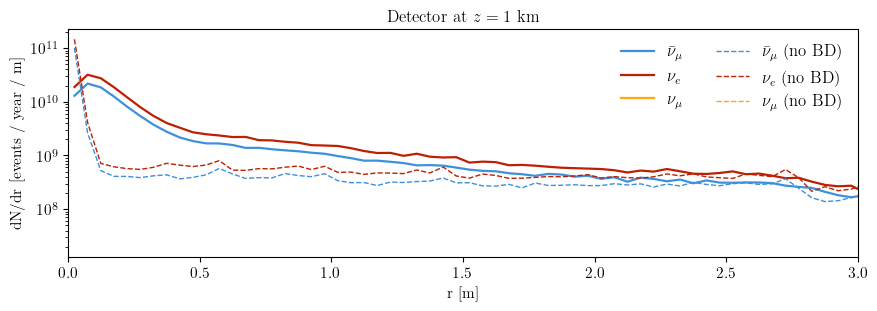

In [13]:
# plot
fig, ax = pt.std_fig(figsize=(10, 3))

r_centers = 0.5 * (r_edges[1:] + r_edges[:-1])
ax.plot(r_centers/100.0, dN_dr_per_year_per_m_numubar, lw=1.6, label=label["numubar"])
ax.plot(r_centers/100.0, dN_dr_per_year_per_m_nue, lw=1.6, label=label["nue"])
ax.plot(r_centers/100.0, dN_dr_per_year_per_m_numu, lw=1.6, label=label["numu"])

plt.gca().set_prop_cycle(None)

ax.plot(r_centers/100.0, dN_dr_per_year_per_m_numubar_noBD, lw=1., ls='--', label=label["numubar"]+r' (no BD)')
ax.plot(r_centers/100.0, dN_dr_per_year_per_m_nue_noBD, lw=1., ls='--', label=label["nue"]+r' (no BD)')
ax.plot(r_centers/100.0, dN_dr_per_year_per_m_numu_noBD, lw=1., ls='--', label=label["numu"]+r' (no BD)')

ax.set_xlabel("r [m]")
ax.set_ylabel("dN/dr [events / year / m]")
ax.set_xlim(0, 3)
# ax.set_xscale
#ax.set_ylim(1e7, None)
ax.set_yscale('log')
ax.legend(frameon=False, fontsize=12, ncol=2)
ax.set_title(r"Detector at $z = 1$ km")
fig.tight_layout()
fig.savefig("plots/hybrid_v06_event_rate_radial.pdf", dpi=300, bbox_inches="tight")

## Estimate forward event rate

Estimated total forward event rate (numubar): 9.722e+09 events/year
Estimated total forward event rate (nue):  8.505e+09 events/year
Estimated total forward event rate (numu):  9.722e+09 events/year


/var/folders/84/k7jzjrjn68595pl9grlw_7cm0000gq/T/ipykernel_45046/3253303844.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


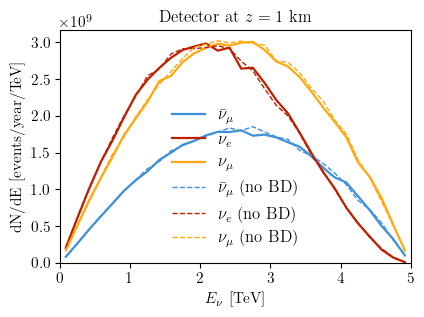

In [14]:
GeV_to_TeV = 1e-3
event_results = {}
for flavor in ["numubar", "nue", "numu"]:
    sigma_tot = xsecs.total_xsecs[flavor](energy_centers)
    p_int = sigma_tot * nucleon_column_density

    # Here we multiply back by the det area.
    dN_dE_per_decay = flux_results[flavor] * detector_area_cm2 * p_int

    # dN/dE per year
    dN_dE_per_year = dN_dE_per_decay * bunches_per_year

    event_results[flavor] = {
        "dN_dE_per_decay": dN_dE_per_decay,
        "dN_dE_per_year": dN_dE_per_year,
    }


for flavor in ["numubar", "nue", "numu"]:
    sigma_tot = xsecs.total_xsecs[flavor](energy_centers)
    p_int = sigma_tot * nucleon_column_density

    # Here we multiply back by the det area.
    dN_dE_per_decay = flux_results[flavor+'_nobd'] * detector_area_cm2 * p_int

    # dN/dE per year
    dN_dE_per_year = dN_dE_per_decay * bunches_per_year

    event_results[flavor+'_nobd'] = {
        "dN_dE_per_decay": dN_dE_per_decay,
        "dN_dE_per_year": dN_dE_per_year,
    }

fig, ax = pt.std_fig()
for flavor in ["numubar", "nue", "numu"]:
    ax.plot(energy_centers*GeV_to_TeV, event_results[flavor]["dN_dE_per_year"]/GeV_to_TeV, lw=1.6, label=label[flavor])
plt.gca().set_prop_cycle(None)
for flavor in ["numubar", "nue", "numu"]:
    ax.plot(energy_centers*GeV_to_TeV, event_results[flavor+"_nobd"]["dN_dE_per_year"]/GeV_to_TeV, lw=1., ls='--', label=label[flavor]+r' (no BD)')
    # ax.set_yscale("log")
ax.set_xlabel(r"$E_\nu$ [TeV]")
ax.set_ylabel(r"dN/dE [events/year/TeV]")
ax.set_xlim(0, 5)
ax.set_ylim(0, None)
ax.legend(frameon=False, fontsize=12)
ax.set_title(r"Detector at $z = 1$ km")
fig.tight_layout()

tot_numu = np.trapezoid(event_results["numubar"]["dN_dE_per_year"], energy_centers)
tot_nue = np.trapezoid(event_results["nue"]["dN_dE_per_year"], energy_centers)
tot_numu = np.trapezoid(event_results["numu"]["dN_dE_per_year"], energy_centers)

print(f"Estimated total forward event rate (numubar): {tot_numu:.3e} events/year")
print(f"Estimated total forward event rate (nue):  {tot_nue:.3e} events/year")
print(f"Estimated total forward event rate (numu):  {tot_numu:.3e} events/year")

fig.savefig("plots/hybrid_v06_event_rate_spectrum.pdf", dpi=300, bbox_inches="tight")

## Compare Event Rates with Previous Neutrino Experiments

In [15]:
# pull data of neutrino experiments
import os
import csv
nu_spectrum_dir = "nu_spectrum_data"
nu_spectrum_arrays = {}
for fname in os.listdir(nu_spectrum_dir):
    if fname.endswith(".csv"):
        arr = []
        with open(os.path.join(nu_spectrum_dir, fname), "r") as f:
            reader = csv.reader(f)
            for row in reader:
                if len(row) >= 2:
                    try:
                        x = float(row[0])
                        y = float(row[1])
                        arr.append((x, y))
                    except ValueError:
                        continue
        key = fname.replace(".csv", "").replace("_", " ")
        nu_spectrum_arrays[key] = arr
# Example: chorus = nu_spectrum_arrays["chorus"]
for key, arr in nu_spectrum_arrays.items():
    globals()[key] = arr

In [16]:
# Compare with case with smaller detector radius (1 m) but same mass

det_radius = 1e2  # cm (1 m radius)

detector_area_cm2 = np.pi * det_radius**2

event_results2 = {}
for flavor in ["numubar", "nue", "numu"]:
    sigma_tot = xsecs.total_xsecs[flavor](energy_centers)
    p_int = sigma_tot * 4 * nucleon_column_density #halving the detector radius means we need to quadruple the column density to keep the same mass

    # Here we multiply back by the det area.
    dN_dE_per_decay = flux_results[flavor] * detector_area_cm2 * p_int

    # dN/dE per year
    dN_dE_per_year = dN_dE_per_decay * bunches_per_year

    event_results2[flavor] = {
        "dN_dE_per_decay": dN_dE_per_decay,
        "dN_dE_per_year": dN_dE_per_year,
    }

In [17]:
# Compare with case where the detector is scaled to 1t detector

det_radius = 2e2  # cm (2 m radius)
detector_mass = 1e6  # g (1 ton)

nucleon_column_density = detector_mass / const.m_proton_in_g / (np.pi * det_radius**2)  # nucleons/cm^2
detector_area_cm2 = np.pi * det_radius**2

event_results3 = {}
for flavor in ["numubar", "nue", "numu"]:
    sigma_tot = xsecs.total_xsecs[flavor](energy_centers)
    p_int = sigma_tot * nucleon_column_density

    # Here we multiply back by the det area.
    dN_dE_per_decay = flux_results[flavor] * detector_area_cm2 * p_int

    # dN/dE per year
    dN_dE_per_year = dN_dE_per_decay * bunches_per_year

    event_results3[flavor] = {
        "dN_dE_per_decay": dN_dE_per_decay,
        "dN_dE_per_year": dN_dE_per_year,
    }

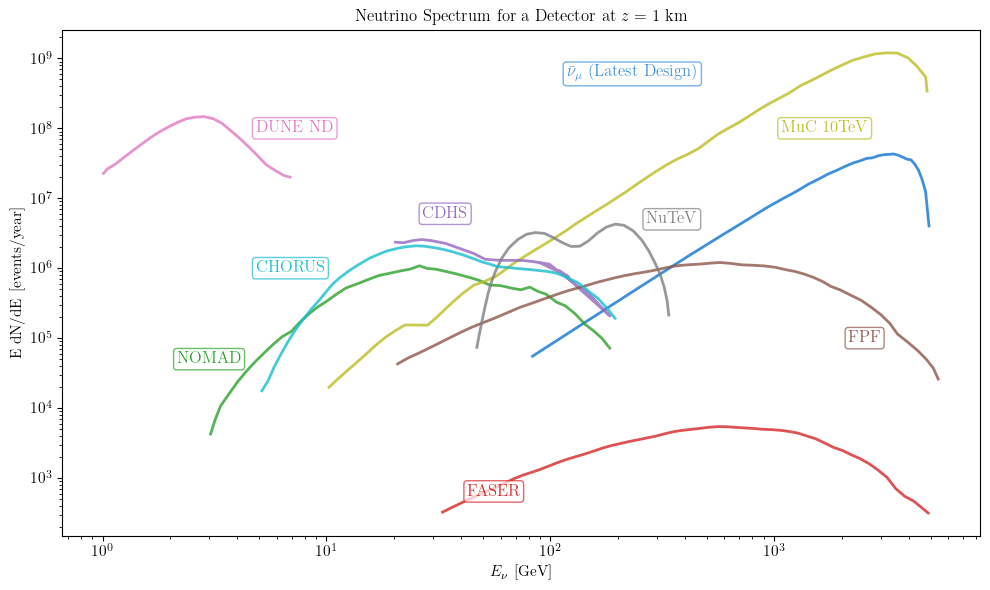

In [18]:
# fig, ax = pt.std_fig()

fig, ax = plt.subplots(figsize=(10, 6))
line_handles = []

line, = ax.plot(energy_centers, event_results3["numubar"]["dN_dE_per_year"]*energy_centers, lw=2, label=label["numubar"]+" (Latest Design)")
line_handles.append(line)
ax.set_xscale("log")
ax.set_yscale("log")

# Plot the sum of numubar and numu for the latest design
# sum_event = event_results["numubar"]["dN_dE_per_year"] * energy_centers + event_results["numu"]["dN_dE_per_year"] * energy_centers
# sum_line, = ax.plot(energy_centers, sum_event, lw=2, label=r"$\bar\nu_\mu + \nu_\mu$ (Latest Design)", color="black")
# ax.set_xscale("log")
# ax.set_yscale("log")

plt.gca().set_prop_cycle(None)

# Plot neutrino experiment data as lines
experiment_colors = ["tab:green", "tab:olive", "tab:purple", "tab:brown", "tab:gray", "tab:pink", "tab:cyan", "tab:red"]
exp_line_handles = []
for i, (exp_name, arr) in enumerate(nu_spectrum_arrays.items()):
    arr = np.array(arr)
    if arr.shape[1] == 2:
        exp_line, = ax.plot(arr[:,0], arr[:,1], linestyle='-', label=exp_name, lw=2, color=experiment_colors[i % len(experiment_colors)], alpha=0.8)
        exp_line_handles.append((exp_line, exp_name))

ax.set_xlabel(r"$E_\nu$ [GeV]")
ax.set_ylabel(r"E dN/dE [events/year]")
# ax.set_xlim(0, 5)
# ax.set_ylim(0, None)
# Remove the default legend
# ax.legend(frameon=False, fontsize=12)
ax.set_title(r"Neutrino Spectrum for a Detector at $z = 1$ km")
fig.tight_layout()

# Annotate each line with its label and color
# Now allow manual adjustment of label positions
# Provide a dictionary for manual label positions: {label: (x, y)}
manual_label_positions = {
    # Example: 'label_text': (x_value, y_value)
    # You can fill these in manually for each line
    r"$\bar\nu_\mu$ (Latest Design)": (110, 6e8),
    r"$\nu_e$ (Latest Design)": (70, 1e8),
    r"MuC 10TeV": (1000, 1e8),
    r"CHORUS": (4.5, 1e6),
    r"DUNE ND": (4.5, 1e8),
    r"NuTeV": (250, 5e6),
    r"FPF": (2000, 1e5),
    r"NOMAD": (2,5e4),
    r"CDHS": (25,6e6),
    r"$\nu_\mu$ (Latest Design)": (300, 2e9),
    "Latest Design": (270, 2e9)
}

def annotate_line(ax, line, label, xdata, ydata):
    if label in manual_label_positions:
        x_pos, y_pos = manual_label_positions[label]
    else:
        # Default: 70% along the line
        x_pos = xdata[int(0.05 * len(xdata))]
        y_pos = ydata[int(0.1 * len(ydata))]
    ax.annotate(label,
                xy=(x_pos, y_pos),
                xytext=(5, 0),
                textcoords='offset points',
                color=line.get_color(),
                fontsize=12,
                va='center',
                ha='left',
                fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec=line.get_color(), lw=1, alpha=0.7))

# Annotate main design lines
annotate_line(ax, line_handles[0], label["numubar"]+" (Latest Design)", energy_centers, event_results["numubar"]["dN_dE_per_year"]*energy_centers)

# annotate_line(ax, sum_line, "Latest Design", energy_centers, sum_event)

# Annotate experiment lines
for exp_line, exp_name in exp_line_handles:
    xdata = exp_line.get_xdata()
    ydata = exp_line.get_ydata()
    # Only annotate if there is data
    if len(xdata) > 0 and len(ydata) > 0:
        annotate_line(ax, exp_line, exp_name, xdata, ydata)

fig.savefig("plots/numubar_spectrum.pdf", dpi=300, bbox_inches="tight")


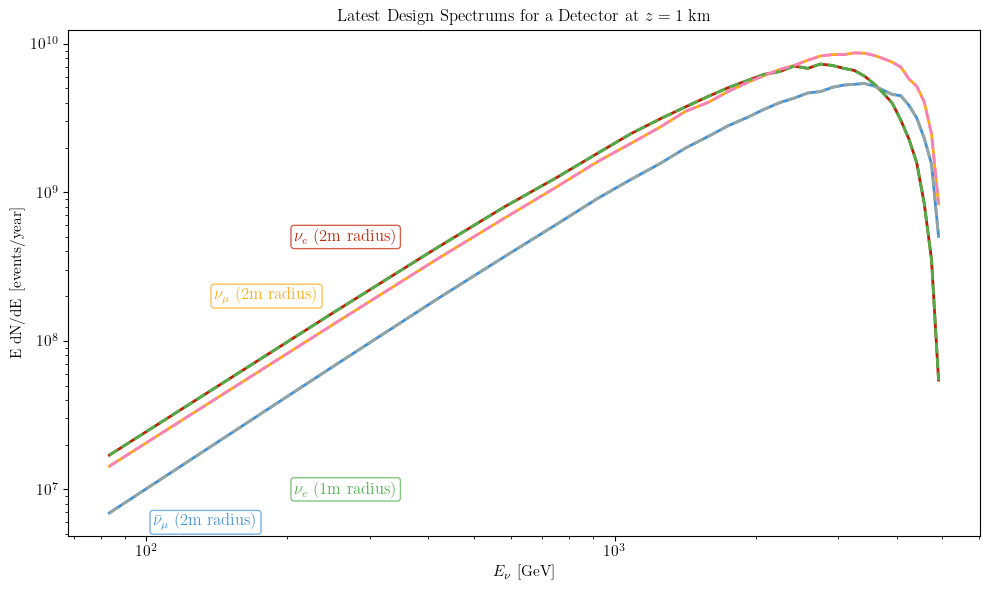

In [19]:
fig, ax = plt.subplots(figsize=(10, 6))
line_handles = []

for flavor in ["numubar", "nue", "numu"]:
    line, = ax.plot(energy_centers, event_results[flavor]["dN_dE_per_year"]*energy_centers, lw=2, label=label[flavor]+" (Latest Design)")
    line_handles.append(line)
    ax.set_xscale("log")
    ax.set_yscale("log")

for flavor in ["numubar", "nue", "numu"]: #Scaled to 1t detector
    line, = ax.plot(energy_centers, event_results2[flavor]["dN_dE_per_year"]*energy_centers, lw=2, label=label[flavor]+" (1t detector)", ls='--')
    line_handles.append(line)
    ax.set_xscale("log")
    ax.set_yscale("log")


ax.set_xlabel(r"$E_\nu$ [GeV]")
ax.set_ylabel(r"E dN/dE [events/year]")
# ax.set_xlim(0, 5)
# ax.set_ylim(0, None)
# Remove the default legend
# ax.legend(frameon=False, fontsize=12)
ax.set_title(r"Latest Design Spectrums for a Detector at $z = 1$ km")
fig.tight_layout()

manual_label_positions.update({
    r"$\bar\nu_\mu$ (2m radius)": (100, 6e6),
    r"$\nu_e$ (2m radius)": (200, 5e8),
    r"$\nu_\mu$ (2m radius)": (135, 2e8),
    r"$\bar\nu_\mu$ (1m radius)": (100, 1e5),
    r"$\nu_e$ (1m radius)": (200, 1e7),
    r"$\nu_\mu$ (1m radius)": (135, 2e6),
})

for i, flavor in enumerate(["numubar", "nue", "numu"]):
    annotate_line(ax, line_handles[i], label[flavor]+" (2m radius)", energy_centers, event_results[flavor]["dN_dE_per_year"]*energy_centers)

for i, flavor in enumerate(["numubar", "nue", "numu"]):
    annotate_line(ax, line_handles[i+3], label[flavor]+" (1m radius)", energy_centers, event_results2[flavor]["dN_dE_per_year"]*energy_centers)

fig.savefig("plots/compare_det_radii_numubar_spectrum.pdf", dpi=300, bbox_inches="tight")